<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Instagram_Posts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('posts.csv')
df.head(11)

,Post_id,Post_Type,comments,likes
0,101,Carousel,268,16382
1,102,Reel,138,9267
2,103,Reel,1089,10100
3,104,Reel,271,6943
4,105,Reel,145,17158
5,106,Reel,143,9683
6,104,Reel,271,6943
7,107,Reel,132,4287
8,108,Reel,128,7484
9,109,Reel,884,48528


In [3]:
df.tail(11)

,Post_id,Post_Type,comments,likes
29,126,Reel,274,27814
30,127,Image,208,45416
31,128,Image,431,42470
32,130,Carousel,287,34232
33,131,Carousel,507,59716
34,132,Image,272,53254
35,133,Carousel,413,58485
36,134,Carousel,254,15159
37,135,Reel,35,1399
38,136,Image,87,4866


In [4]:
df.shape

(40, 4)

In [5]:
df.columns

Index(['Post_id', 'Post_Type', 'comments', 'likes'], dtype='object')

In [6]:
df.dtypes

,0
Post_id,int64
Post_Type,object
comments,int64
likes,int64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Post_id    40 non-null     int64 
 1   Post_Type  40 non-null     object
 2   comments   40 non-null     int64 
 3   likes      40 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.4+ KB


In [8]:
df.describe(include = 'all')

,Post_id,Post_Type,comments,likes
count,40.000000,40,40.00000,40.000000
unique,NaN,3,NaN,NaN
top,NaN,Carousel,NaN,NaN
freq,NaN,15,NaN,NaN
mean,116.950000,NaN,216.37500,18098.725000
std,10.703342,NaN,239.49741,21656.873353
min,101.000000,NaN,1.00000,160.000000
25%,107.750000,NaN,19.00000,1276.000000
50%,116.500000,NaN,144.00000,7213.500000
75%,125.250000,NaN,272.50000,29418.500000


# Univarite Analysis

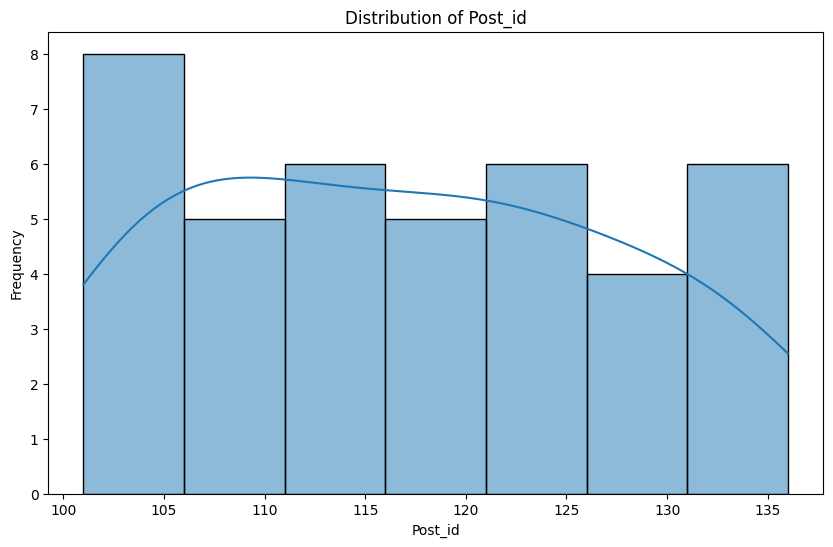

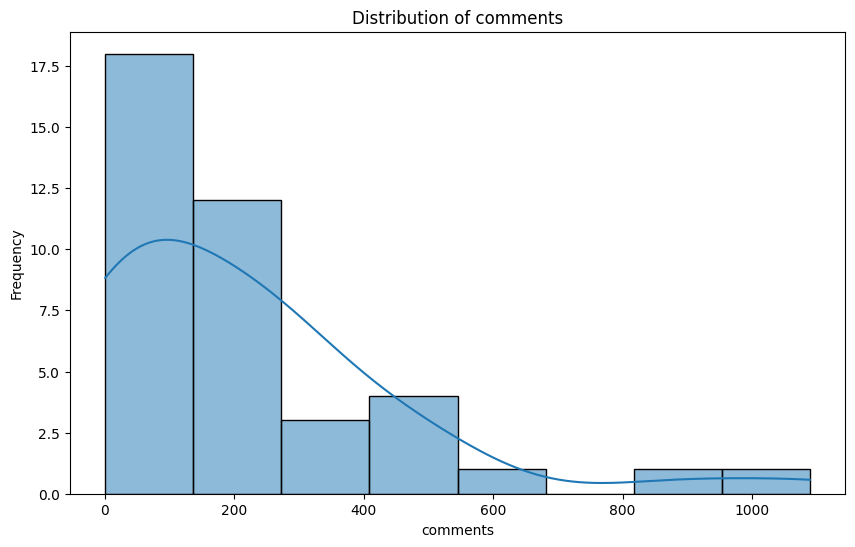

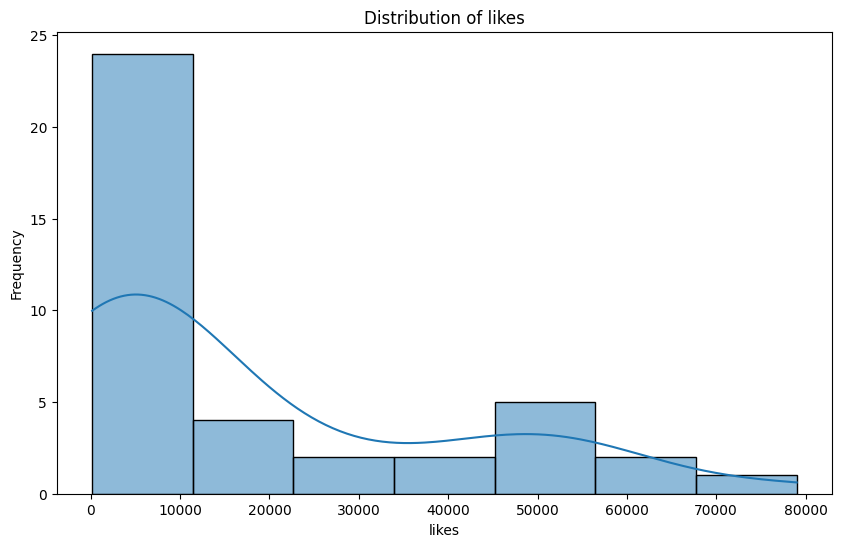

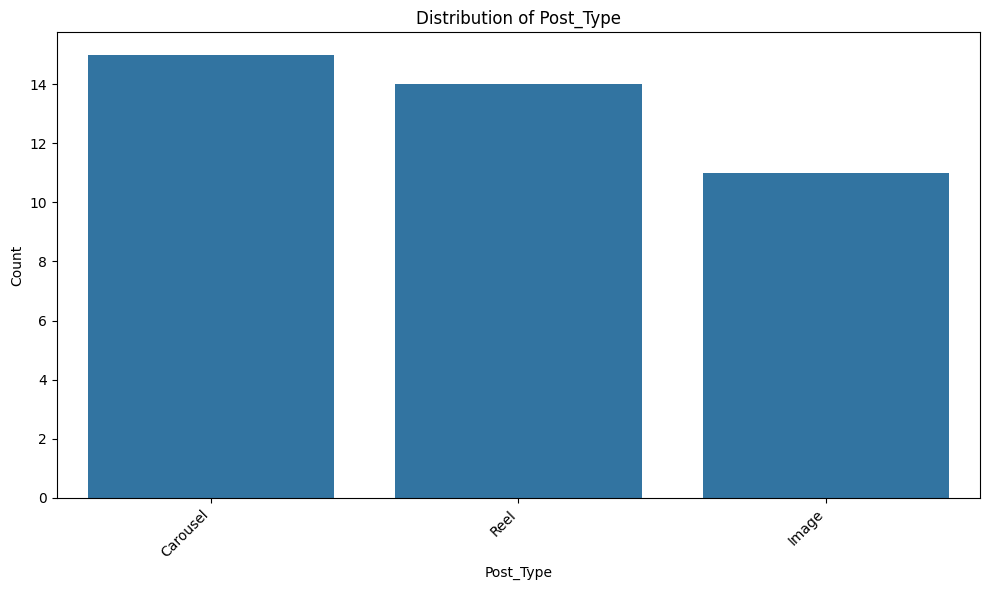

Value counts for Post_Type:
Post_Type
Carousel    15
Reel        14
Image       11
Name: count, dtype: int64



In [9]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

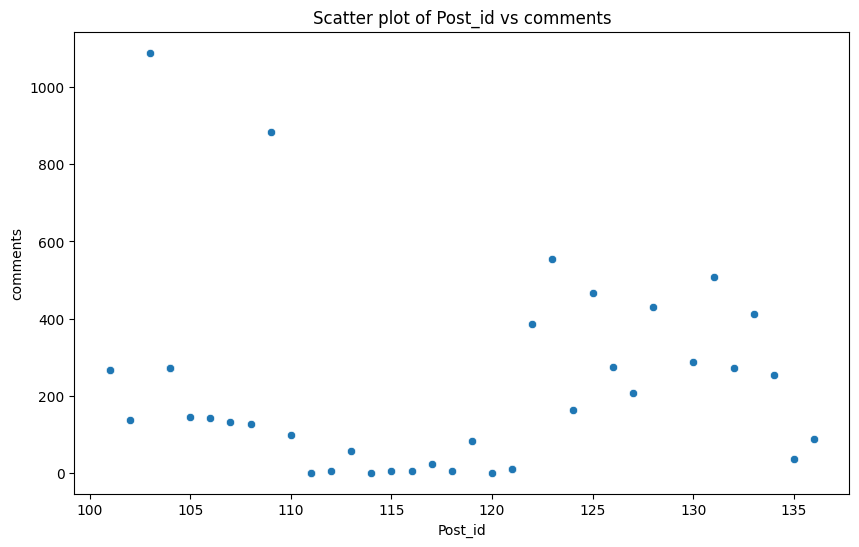

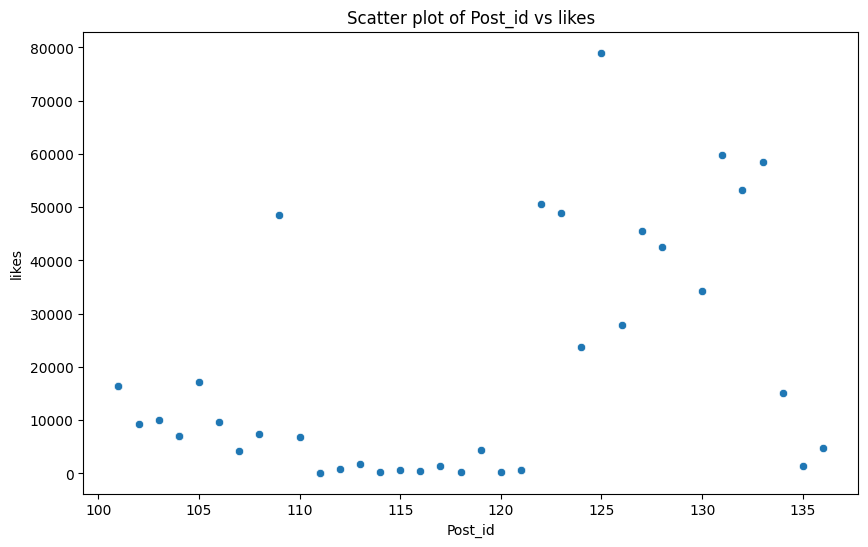

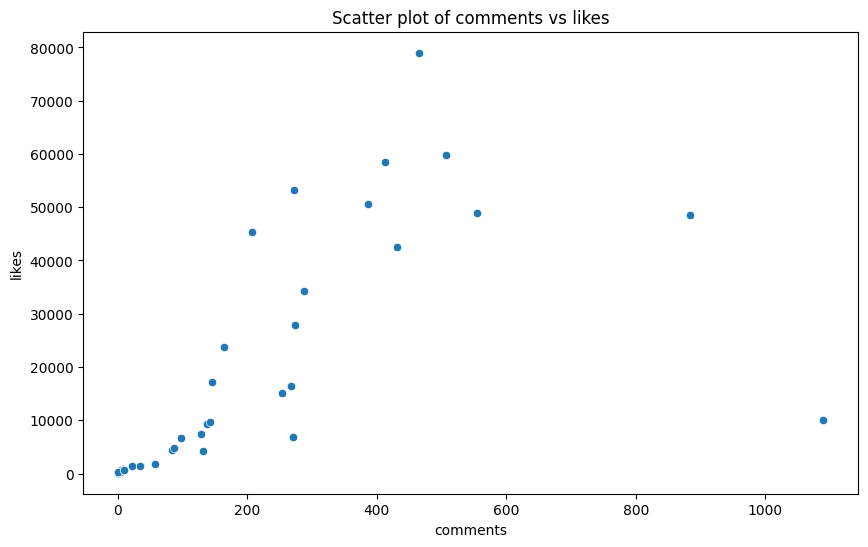

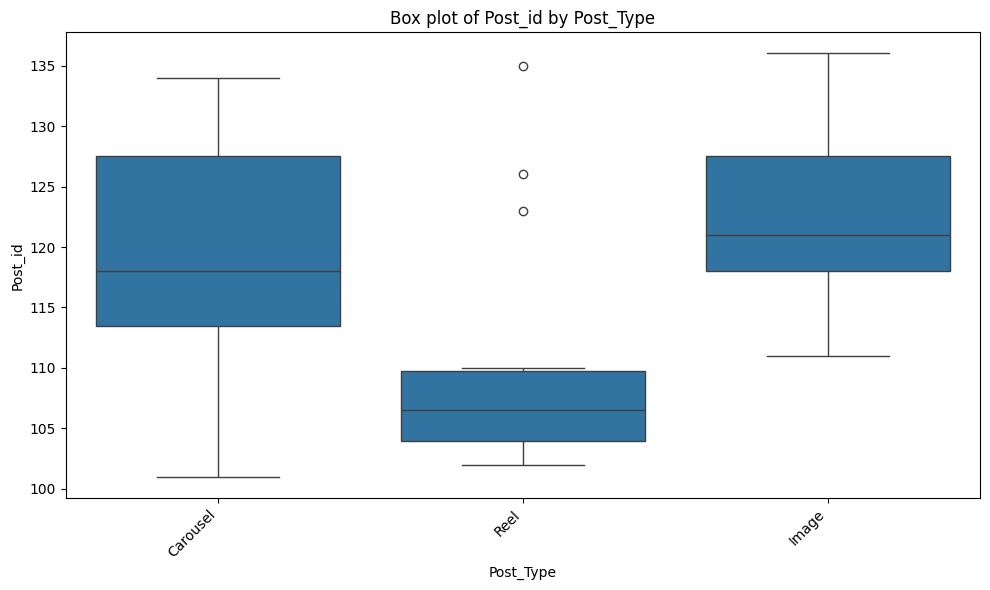

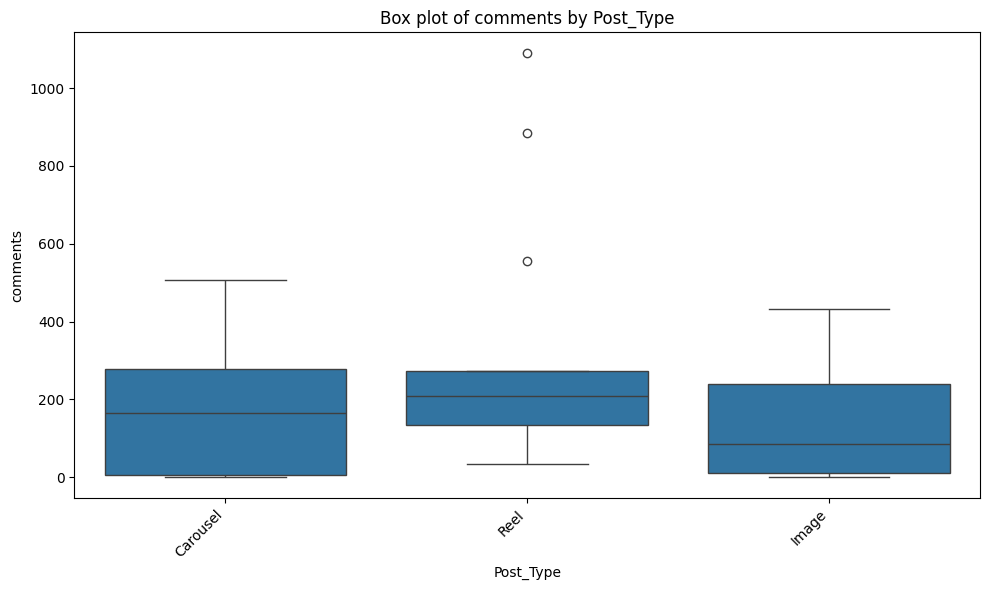

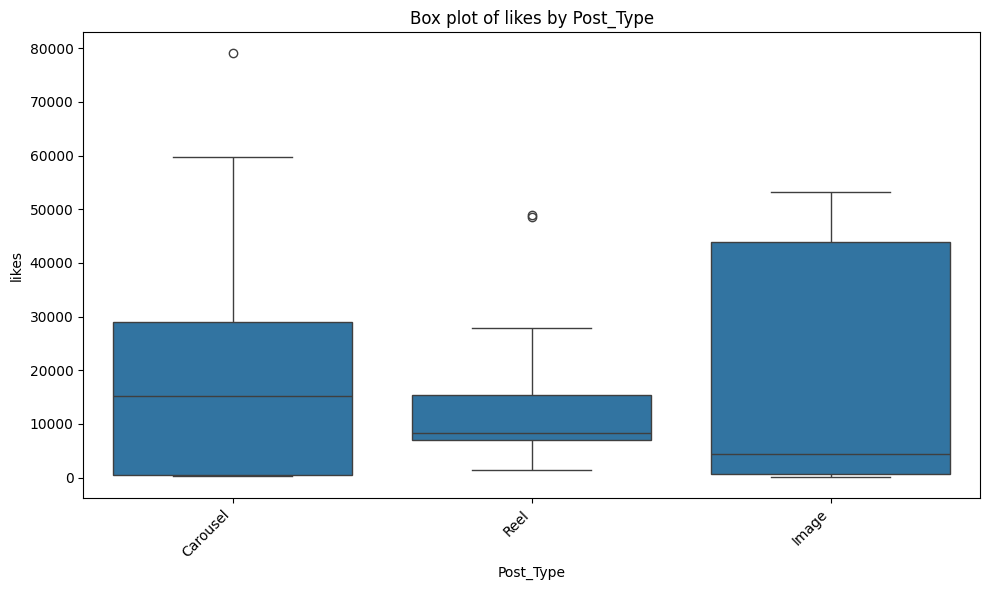

In [10]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

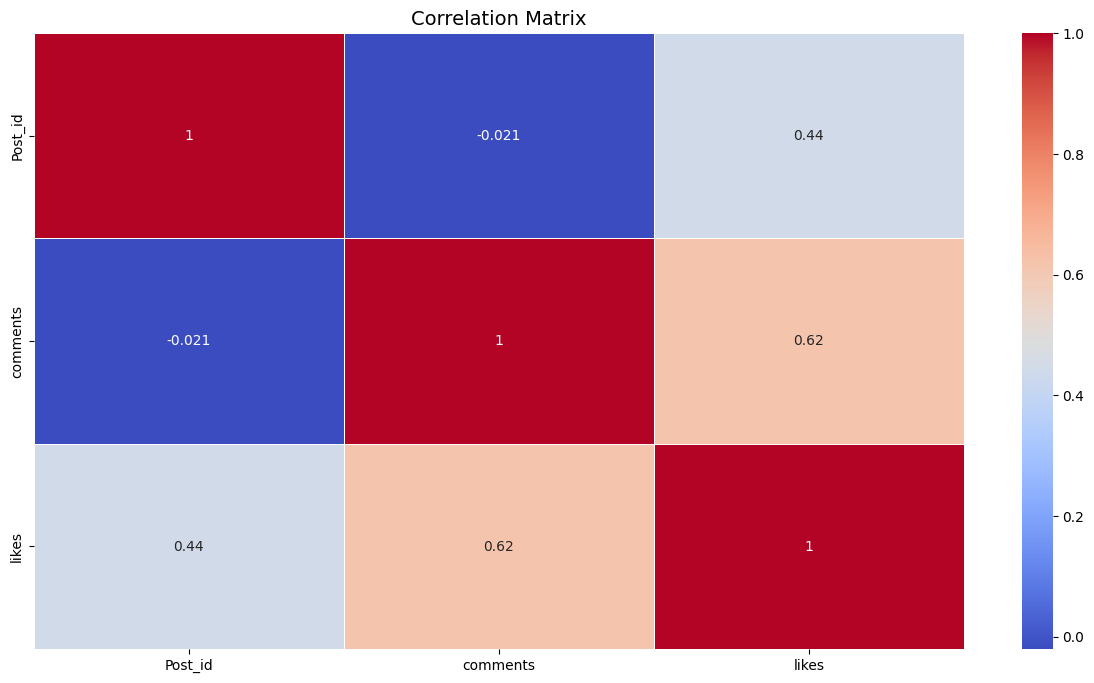

In [11]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank you